# Experiment D - Mixed Raw + Reconstruction Training

**Question:** can exposure to both raw and reconstructed acceleration during training improve domain robustness and held-out-user generalization?

Strict D2 protocol:

1. Reuse Experiment A's **train / validation / test users** and `class_to_idx` from the A checkpoint.
2. Use the A checkpoint **only for split/class metadata**. Do **not** reuse A model weights or normalization.
3. Fit normalization on **mixed training data**: each training segment contributes both raw and reconstruction valid samples.
4. Train one new `MaskAwareAccelerationCNN` from scratch on the duplicated mixed training set.
5. Select the best epoch using **mixed validation balanced accuracy**.
6. Freeze the selected model and evaluate the **same model** on:
   - raw held-out-user test data;
   - reconstructed held-out-user test data.
7. Use the same mixed-train gallery/prototypes/probe-training data in both representation evaluations.
8. Compute paired raw/reconstruction embedding preservation for the same test samples.
9. Use the same selected dataset roots as the A checkpoint; changing the action/sample cohort requires regenerating A.

The executable experiment lives in `scripts/run_experiment_d.py`; this notebook is intentionally a thin inspection layer.


In [1]:
from __future__ import annotations

from dataclasses import replace
import json
from pathlib import Path
import sys

import pandas as pd
import torch


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing the 'snn' directory."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
SCRIPTS_DIR = REPOSITORY_ROOT / "scripts"

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from snn.accel_reconstruction_eval import experiment_d_config
from run_experiment_d import run_experiment_d

print("Repository root:", REPOSITORY_ROOT)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
CUDA available: True


## Paths and experiment controls

The reference A checkpoint is used only to recover the exact split and class mapping. Keep `ALLOW_NEW_SPLIT=False` for strict A/B/C/D comparability.

Regenerate Experiment A before running B/C/D whenever A's exclusions change. D has no local cohort or explicit-split override.


In [2]:
# Select the same one or two roots used to produce REFERENCE_A_CHECKPOINT.
# Roots remain separate on disk and are combined only in the shared loader.
DATASET_ROOTS = [
    Path("outputs/action0_rectified/low-pass/aligned-board-events"),
    Path("outputs/action1_rectified/low-pass/aligned-board-events"),
]
REFERENCE_A_CHECKPOINT = Path(
    "notebooks/artifacts/acceleration_cnn_representation/"
    "best_acceleration_cnn.pt"
)
OUTPUT_DIR = Path(
    "notebooks/artifacts/experiment_D_mixed_training"
)

ALLOW_NEW_SPLIT = False

# Training overrides. Defaults match the current baseline/C configuration.
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 10
BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
USE_CLASS_WEIGHTS = False
GRAD_CLIP_NORM = None
MAX_TRAIN_BATCHES = None
USE_GPU = True


## Build the Experiment D configuration

The nominal config uses `test_source="raw"`, but the D runner always evaluates both raw and reconstruction test domains using the same trained model.


In [3]:
config = experiment_d_config(
    test_source="raw",
    output_dir=OUTPUT_DIR,
    random_seed=12345,
)

config = replace(
    config,
    use_gpu=USE_GPU,
    loader=replace(
        config.loader,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    training=replace(
        config.training,
        num_epochs=NUM_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        use_class_weights=USE_CLASS_WEIGHTS,
        grad_clip_norm=GRAD_CLIP_NORM,
        max_train_batches=MAX_TRAIN_BATCHES,
    ),
)
config.validate()
config.to_dict()


{'name': 'D_mixed_to_raw',
 'train_source': 'mixed',
 'val_source': 'mixed',
 'test_source': 'raw',
 'normalization_source': 'mixed',
 'training_enabled': True,
 'random_seed': 12345,
 'use_gpu': True,
 'normalization_chunk_segments': 256,
 'split': {'train_fraction': 0.7,
  'val_fraction': 0.15,
  'explicit_train_users': None,
  'explicit_val_users': None,
  'explicit_test_users': None,
  'require_all_users_assigned': True,
  'require_all_labels_in_all_splits': True,
  'excluded_users': (),
  'included_labels': None},
 'loader': {'batch_size': 128,
  'num_workers': 0,
  'pin_memory': None,
  'persistent_workers': None},
 'training': {'num_epochs': 30,
  'learning_rate': 0.0005,
  'weight_decay': 0.0,
  'use_class_weights': False,
  'early_stopping_patience': 10,
  'max_train_batches': None,
  'grad_clip_norm': None},
 'evaluation': {'k_values': (1, 3, 5, 10, 20, 50),
  'knn_k_candidates': (1, 3, 5, 7, 10, 15, 20),
  'similarity_query_batch_size': 128,
  'linear_probe': {'epochs': 200,

## Run Experiment D

This performs:

`load -> recover A split -> fit mixed normalization -> mixed train/val -> select best epoch -> raw test + reconstruction test -> paired preservation -> save artifacts`


In [4]:
run = run_experiment_d(
    root=DATASET_ROOTS,
    repository_root=REPOSITORY_ROOT,
    output_dir=OUTPUT_DIR,
    reference_checkpoint=REFERENCE_A_CHECKPOINT,
    config=config,
    allow_new_split=ALLOW_NEW_SPLIT,
)


Epoch 001 | train loss=2.38091, BA=0.15557 | val loss=2.41265, BA=0.17008
Epoch 002 | train loss=2.16123, BA=0.27633 | val loss=2.22284, BA=0.32121
Epoch 003 | train loss=2.02881, BA=0.34444 | val loss=2.07239, BA=0.30638
Epoch 004 | train loss=1.90671, BA=0.38938 | val loss=2.05936, BA=0.27252
Epoch 005 | train loss=1.80543, BA=0.47951 | val loss=1.88907, BA=0.29211
Epoch 006 | train loss=1.70045, BA=0.47250 | val loss=1.77061, BA=0.39311
Epoch 007 | train loss=1.60383, BA=0.53550 | val loss=1.78816, BA=0.36223
Epoch 008 | train loss=1.51155, BA=0.54927 | val loss=1.95503, BA=0.25982
Epoch 009 | train loss=1.44762, BA=0.59065 | val loss=1.70040, BA=0.40471
Epoch 010 | train loss=1.33293, BA=0.65754 | val loss=1.63284, BA=0.43547
Epoch 011 | train loss=1.26496, BA=0.67913 | val loss=1.48370, BA=0.50837
Epoch 012 | train loss=1.22009, BA=0.69950 | val loss=1.75503, BA=0.36342
Epoch 013 | train loss=1.13059, BA=0.73208 | val loss=1.48835, BA=0.48076
Epoch 014 | train loss=1.05422, BA=0.7

## Inherited cohort provenance

Experiment D inherits the cohort from the authoritative A checkpoint.


In [5]:
provenance = json.loads(
    (run.output_dir / "provenance.json").read_text(encoding="utf-8")
)
display(
    pd.Series(
        {
            "cohort_source": provenance["cohort_source"],
            "excluded_users": provenance["excluded_users"],
            "eligible_users": provenance["eligible_users"],
            "train_users": provenance["train_users"],
            "val_users": provenance["val_users"],
            "test_users": provenance["test_users"],
            "class_to_idx": provenance["class_to_idx"],
        },
        name="Inherited cohort",
    )
)


cohort_source                                            checkpoint
excluded_users                                                   []
eligible_users    [user_0, user_1, user_2, user_3, user_4, user_...
train_users       [user_0, user_1, user_3, user_4, user_5, user_...
val_users                                [user_8, user_14, user_20]
test_users                               [user_2, user_13, user_16]
class_to_idx      {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': ...
Name: Inherited cohort, dtype: object

## Training and split checks


In [6]:
display(run.split_summary)
display(run.label_split_counts)
display(run.classification_splits)
display(run.training_history.tail(12))
print("Normalization fitted on:", run.normalization.fitted_on)
print("Best checkpoint:", run.checkpoint_path)


,users,samples,labels
split,,,
train,14,657,12
val,3,127,12
test,3,127,12


split,train,val,test
label,,,
A,51,10,11
B,56,10,9
C,60,12,12
D,58,11,11
E,58,10,12
G,52,12,12
H,61,12,12
I,57,12,11
J,58,11,12


,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train_mixed,0.783105,0.782372,0.788910,0.786617,0.808931
val_mixed,0.614173,0.612311,0.613443,0.609604,1.197267
test_raw,0.574803,0.555285,0.561578,0.574480,1.177424
test_reconstruction,0.566929,0.549904,0.531567,0.542579,1.227764


,epoch,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
48,25,train,0.923135,0.921429,0.923386,0.923438,0.539022
49,25,val,0.606299,0.611788,0.593659,0.591925,1.127477
50,26,train,0.926941,0.926140,0.927256,0.926656,0.522524
51,26,val,0.496063,0.490061,0.466763,0.467831,1.376293
52,27,train,0.931507,0.929841,0.931757,0.931377,0.480432
53,27,val,0.476378,0.455858,0.404173,0.411394,1.485434
54,28,train,0.953577,0.953216,0.953300,0.953577,0.435497
55,28,val,0.559055,0.557540,0.558794,0.558477,1.218177
56,29,train,0.963470,0.964036,0.964259,0.963464,0.390769
57,29,val,0.413386,0.399549,0.345180,0.346723,1.669936


Normalization fitted on: mixed:train
Best checkpoint: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_D_mixed_training/best_acceleration_cnn.pt


## Dual-domain representation results

The two summaries below use the same mixed-trained CNN and the same mixed train/validation reference embeddings. Only the held-out test input domain changes.


In [7]:
print("D: mixed training -> raw test")
display(run.raw_summary.T.rename(columns={0: "value"}))

print("D: mixed training -> reconstruction test")
display(run.reconstruction_summary.T.rename(columns={0: "value"}))


D: mixed training -> raw test


,value
CNN_test_balanced_accuracy,0.555285
CNN_test_accuracy,0.574803
CNN_test_macro_f1,0.561578
kNN_selected_k,5.000000
kNN_test_balanced_accuracy,0.552850
kNN_test_accuracy,0.574803
kNN_test_macro_f1,0.525403
prototype_test_balanced_accuracy,0.591570
prototype_test_accuracy,0.606299
prototype_test_macro_f1,0.561646


D: mixed training -> reconstruction test


,value
CNN_test_balanced_accuracy,0.549904
CNN_test_accuracy,0.566929
CNN_test_macro_f1,0.531567
kNN_selected_k,5.000000
kNN_test_balanced_accuracy,0.603355
kNN_test_accuracy,0.614173
kNN_test_macro_f1,0.588977
prototype_test_balanced_accuracy,0.589466
prototype_test_accuracy,0.598425
prototype_test_macro_f1,0.580573


## Direct raw-vs-reconstruction comparison for the mixed-trained model


In [8]:
display(run.domain_comparison)

comparison = run.domain_comparison.copy()
if {
    "D_mixed_to_raw",
    "D_mixed_to_reconstruction",
}.issubset(comparison.columns):
    comparison["delta_reconstruction_minus_raw"] = (
        comparison["D_mixed_to_reconstruction"]
        - comparison["D_mixed_to_raw"]
    )
display(comparison)


,D_mixed_to_raw,D_mixed_to_reconstruction
metric,,
CNN_test_balanced_accuracy,0.555285,0.549904
CNN_test_accuracy,0.574803,0.566929
CNN_test_macro_f1,0.561578,0.531567
kNN_selected_k,5.000000,5.000000
kNN_test_balanced_accuracy,0.552850,0.603355
kNN_test_accuracy,0.574803,0.614173
kNN_test_macro_f1,0.525403,0.588977
prototype_test_balanced_accuracy,0.591570,0.589466
prototype_test_accuracy,0.606299,0.598425


,D_mixed_to_raw,D_mixed_to_reconstruction,delta_reconstruction_minus_raw
metric,,,
CNN_test_balanced_accuracy,0.555285,0.549904,-0.005381
CNN_test_accuracy,0.574803,0.566929,-0.007874
CNN_test_macro_f1,0.561578,0.531567,-0.030010
kNN_selected_k,5.000000,5.000000,0.000000
kNN_test_balanced_accuracy,0.552850,0.603355,0.050505
kNN_test_accuracy,0.574803,0.614173,0.039370
kNN_test_macro_f1,0.525403,0.588977,0.063574
prototype_test_balanced_accuracy,0.591570,0.589466,-0.002104
prototype_test_accuracy,0.606299,0.598425,-0.007874


## Paired preservation

These diagnostics compare the same held-out test samples before and after reconstruction, under the same mixed-trained model.


In [9]:
display(run.paired_summary)
display(run.paired_transitions)


,mean_embedding_cosine_similarity,median_embedding_cosine_similarity,mean_embedding_cosine_distance,median_embedding_cosine_distance,prediction_agreement
0,0.966328,0.969746,0.033672,0.030254,0.622047


,transition,count,fraction
0,reference_correct -> query_correct,55,0.433071
1,reference_wrong -> query_wrong,37,0.291339
2,reference_correct -> query_wrong,18,0.141732
3,reference_wrong -> query_correct,17,0.133858


## Saved artifacts


In [10]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in sorted(run.artifact_paths.items())
    ]
)
display(artifact_table)


,artifact,path
0,checkpoint,/home/ted/project/writingring-viz/notebooks/ar...
1,classification_splits,/home/ted/project/writingring-viz/notebooks/ar...
2,condition_summaries,/home/ted/project/writingring-viz/notebooks/ar...
3,domain_comparison,/home/ted/project/writingring-viz/notebooks/ar...
4,embeddings_test_raw,/home/ted/project/writingring-viz/notebooks/ar...
5,embeddings_test_reconstruction,/home/ted/project/writingring-viz/notebooks/ar...
6,embeddings_train_mixed,/home/ted/project/writingring-viz/notebooks/ar...
7,embeddings_val_mixed,/home/ted/project/writingring-viz/notebooks/ar...
8,label_split_counts,/home/ted/project/writingring-viz/notebooks/ar...
9,paired_arrays,/home/ted/project/writingring-viz/notebooks/ar...


# Visualization

The cells below are presentation-only. They consume the metrics and embeddings already generated by `run_experiment_d()`.

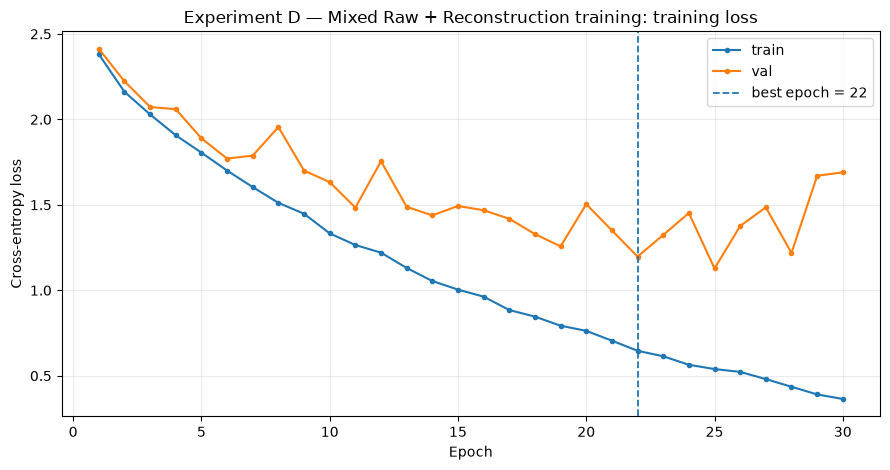

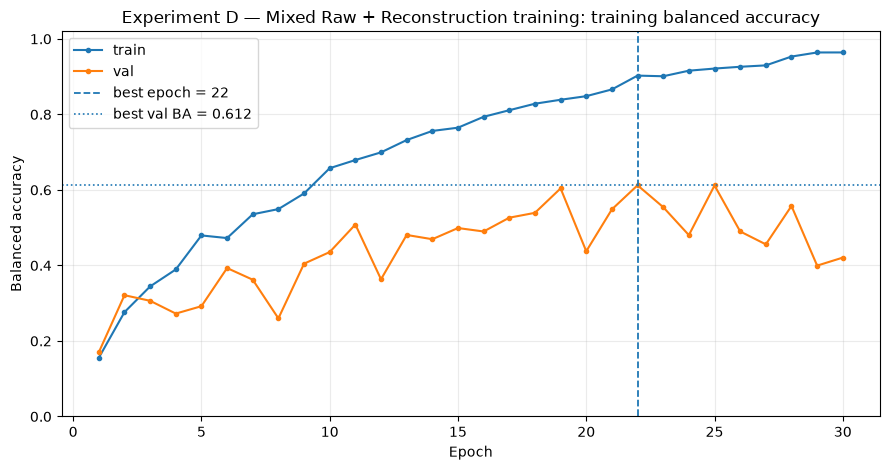

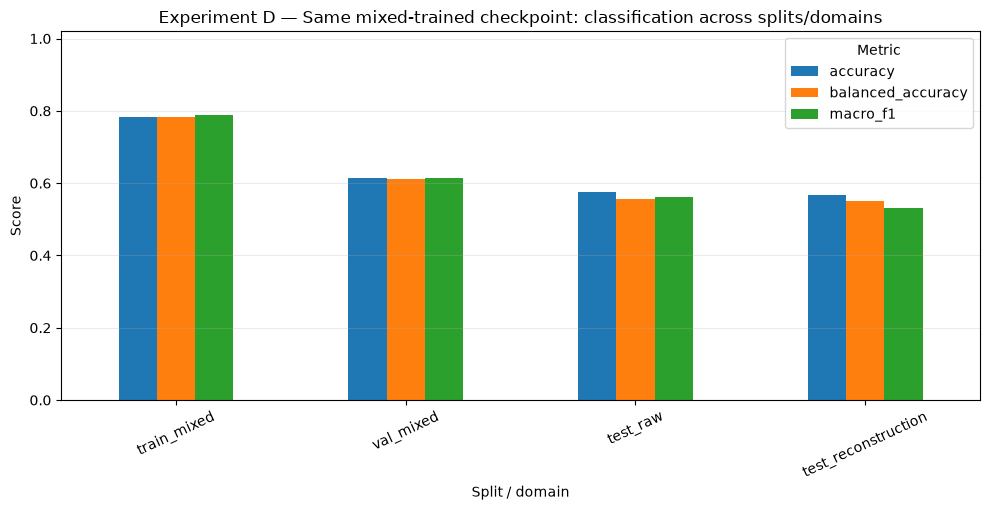

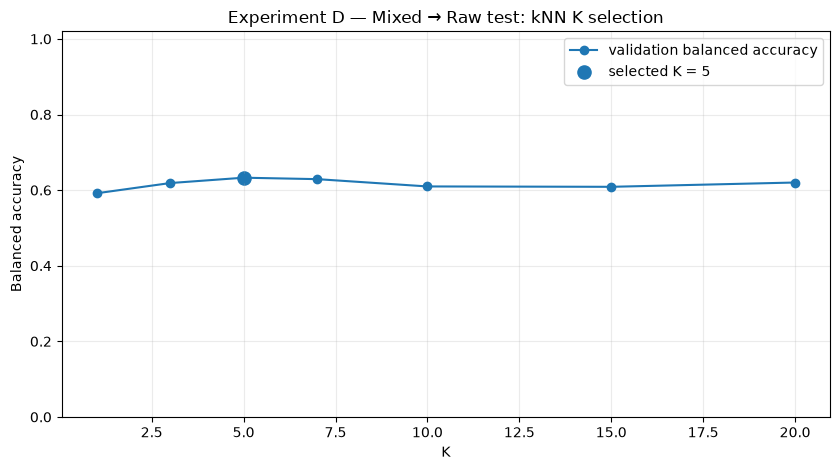

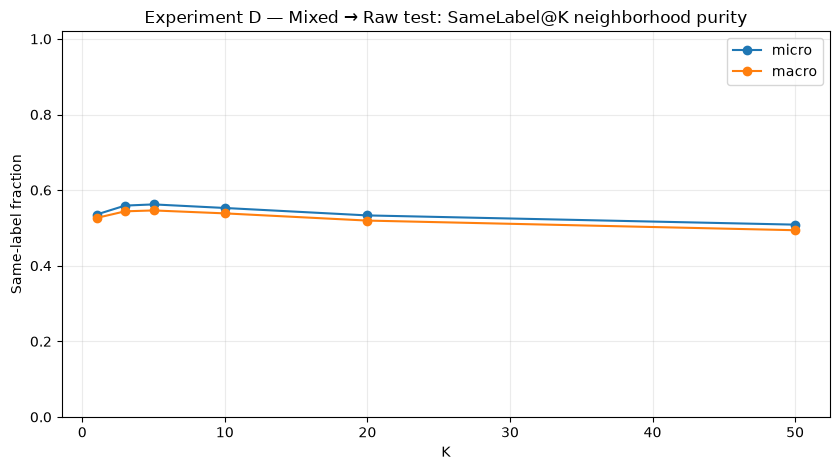

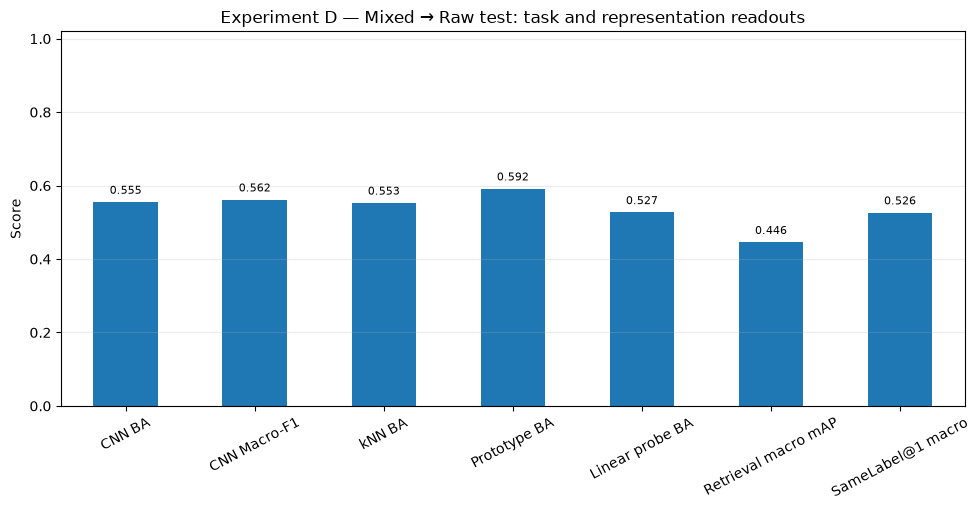

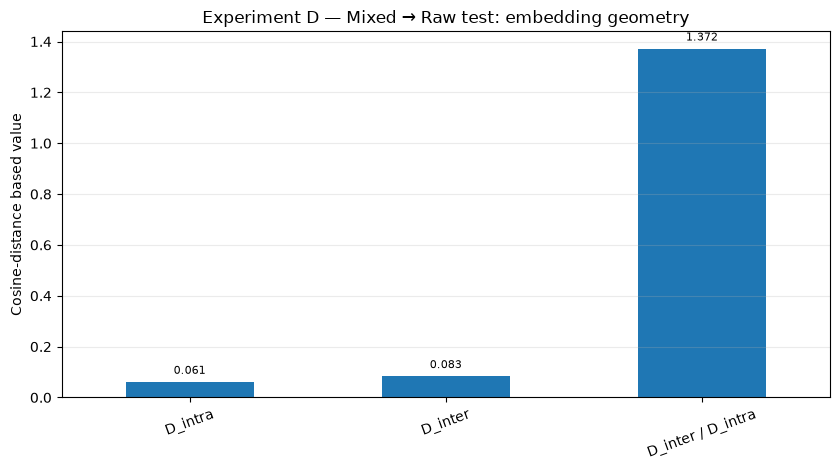

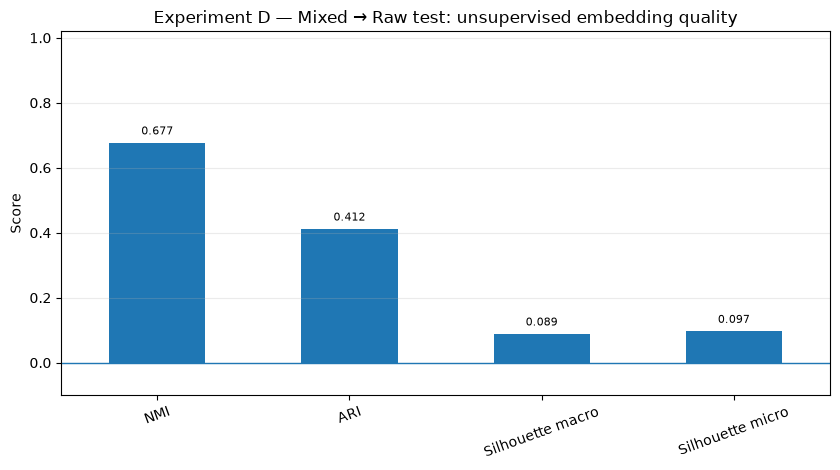

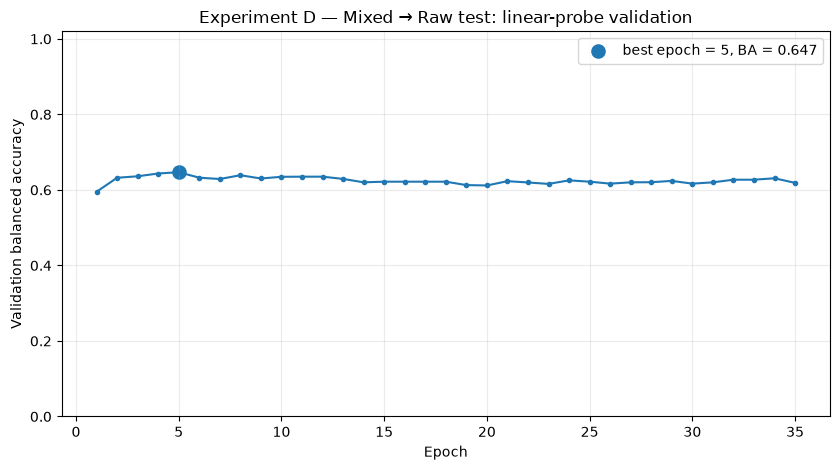

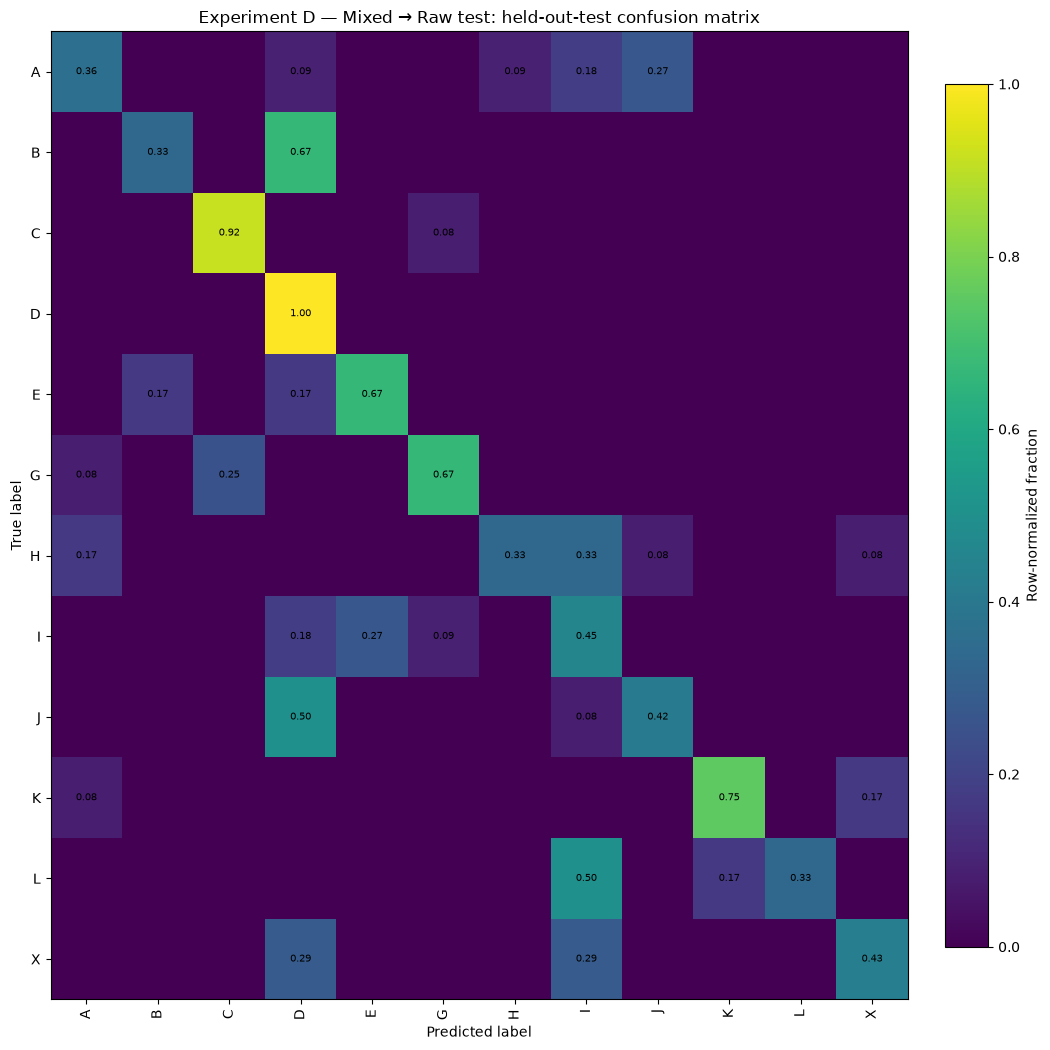

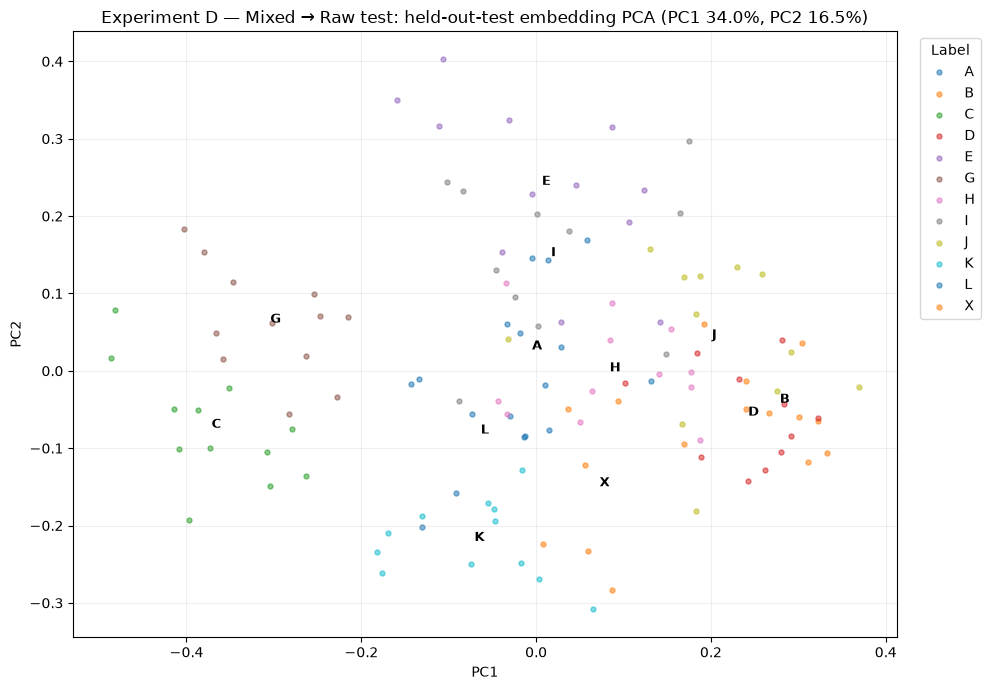

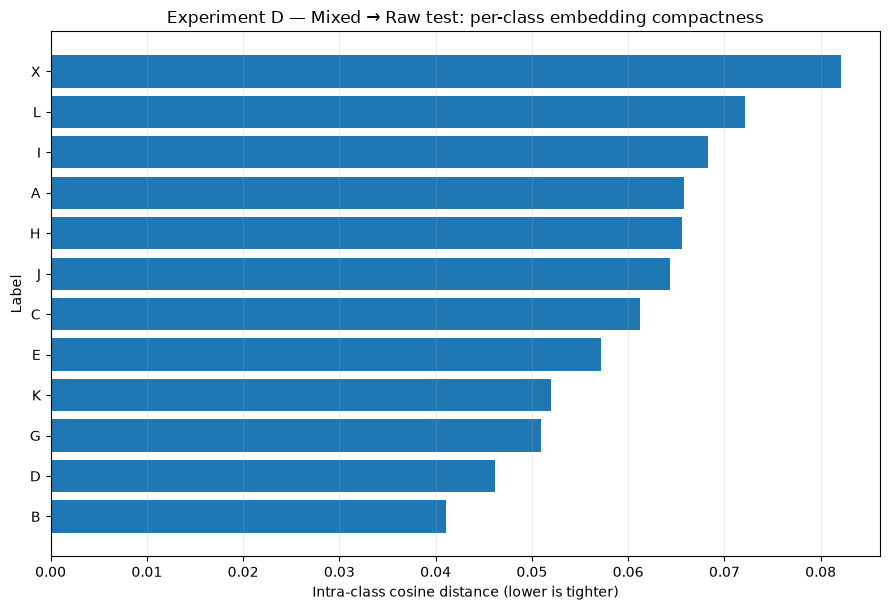

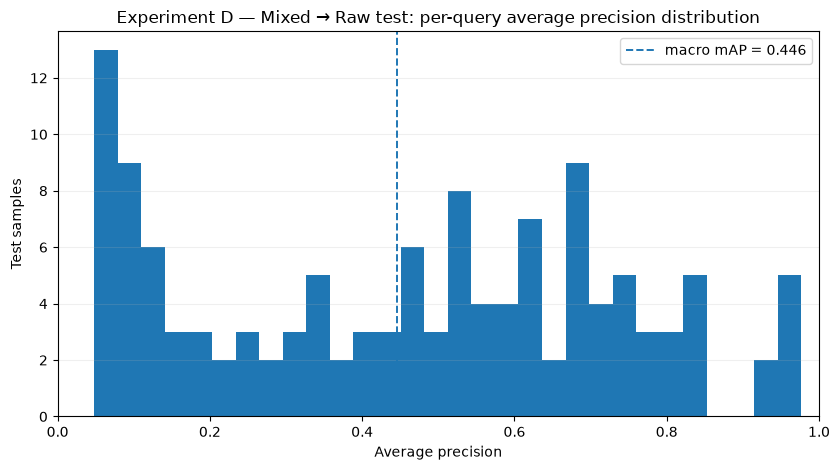

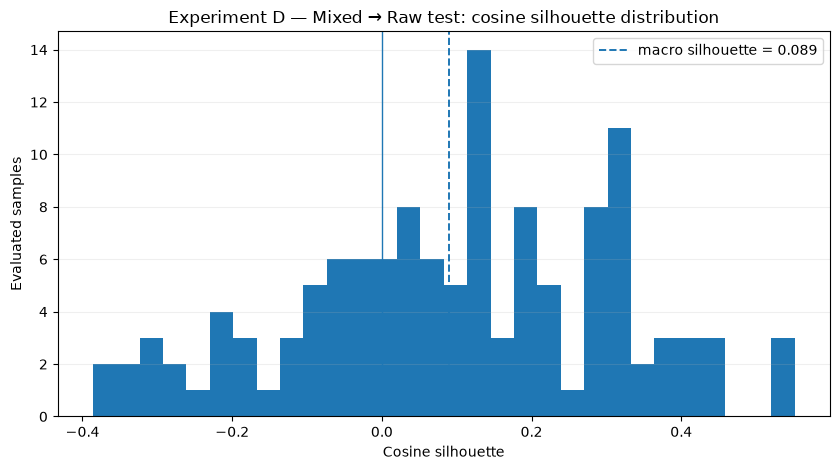

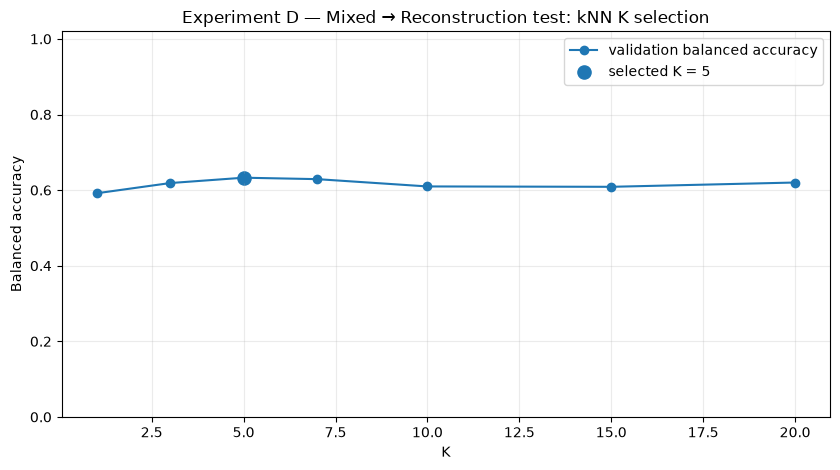

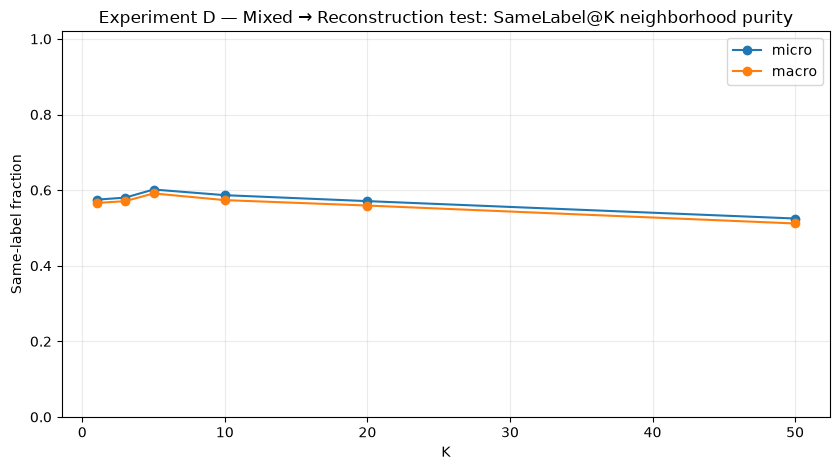

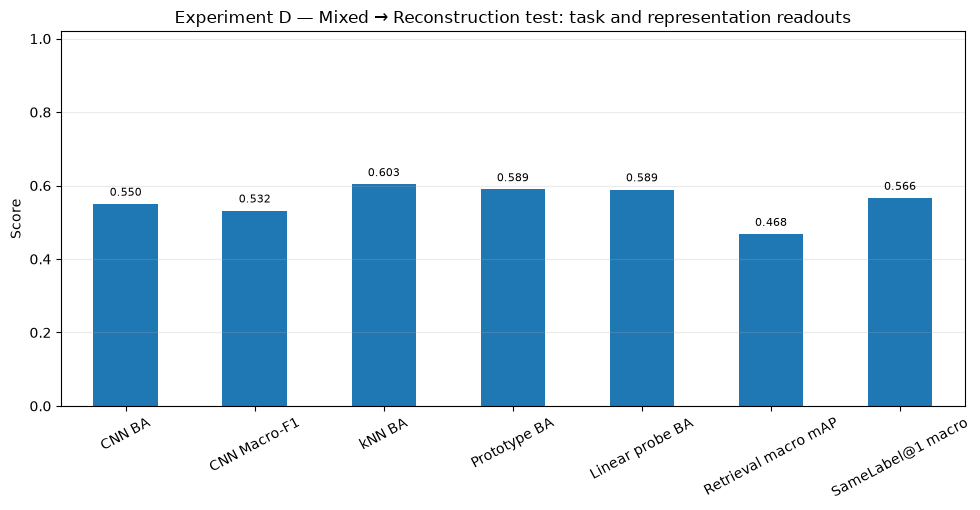

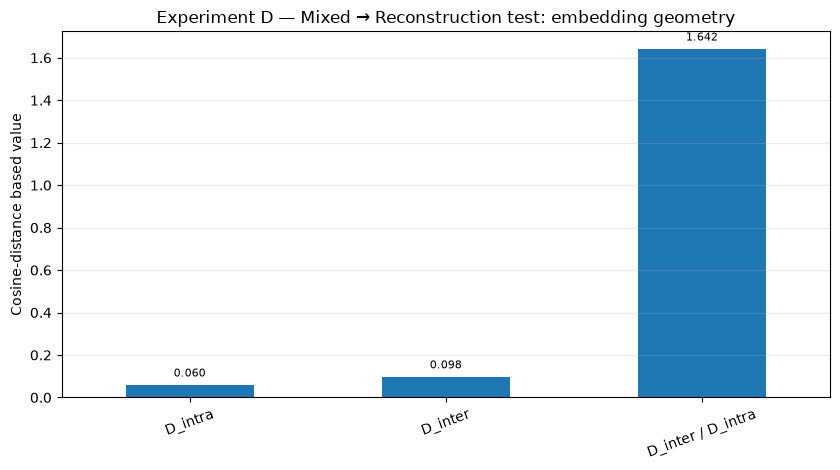

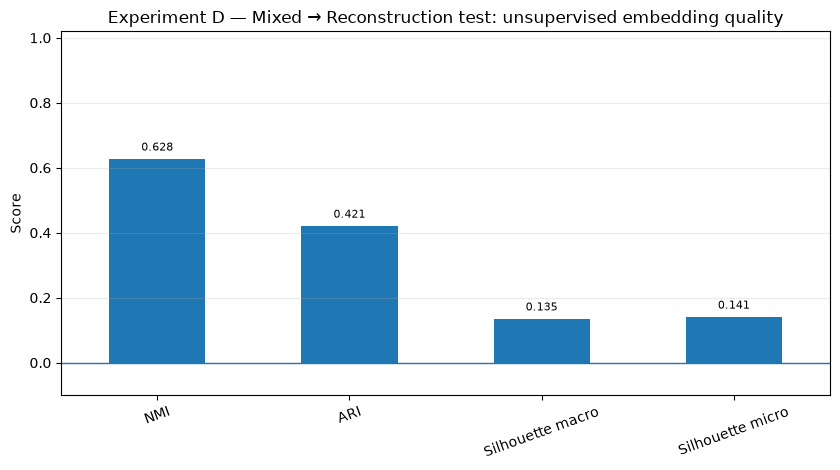

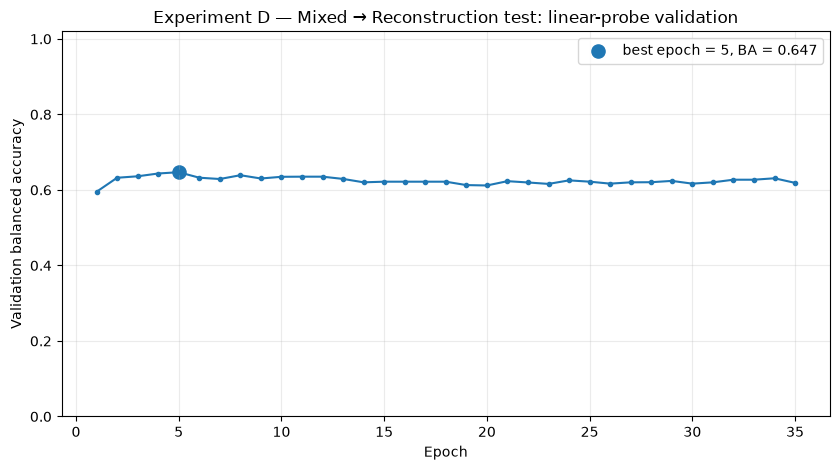

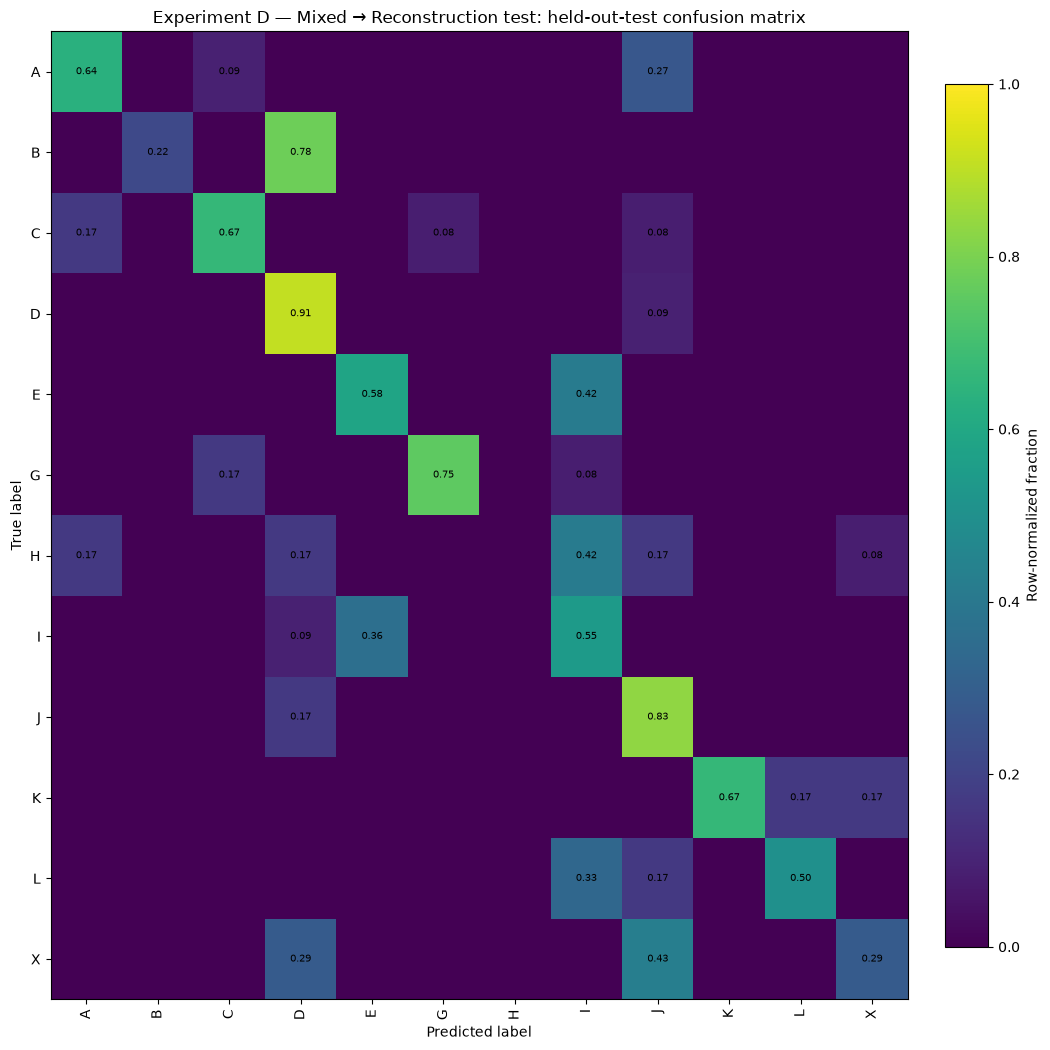

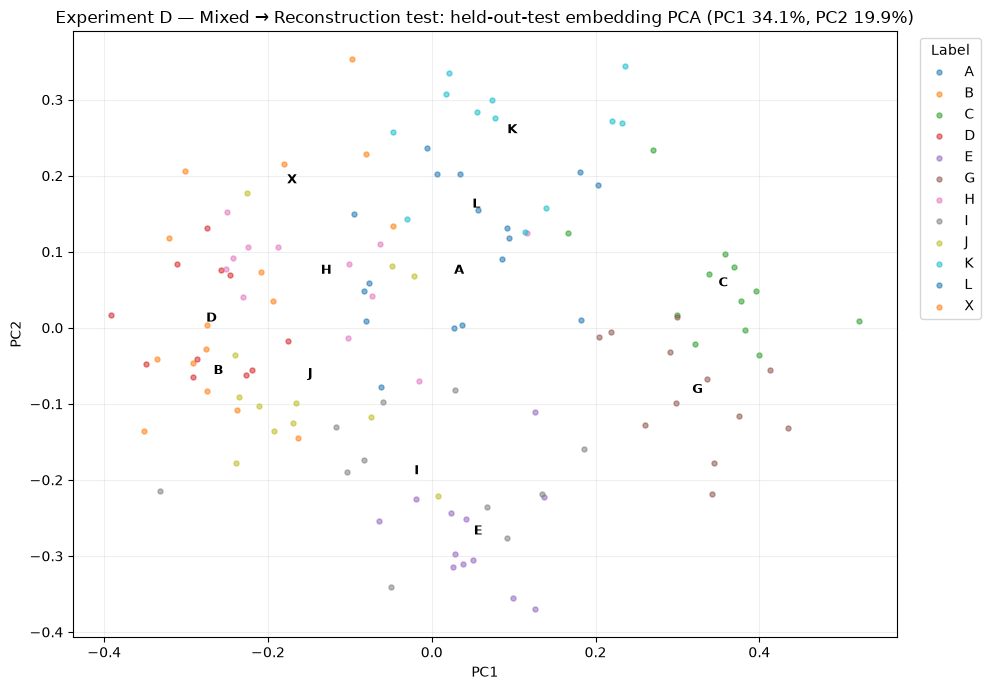

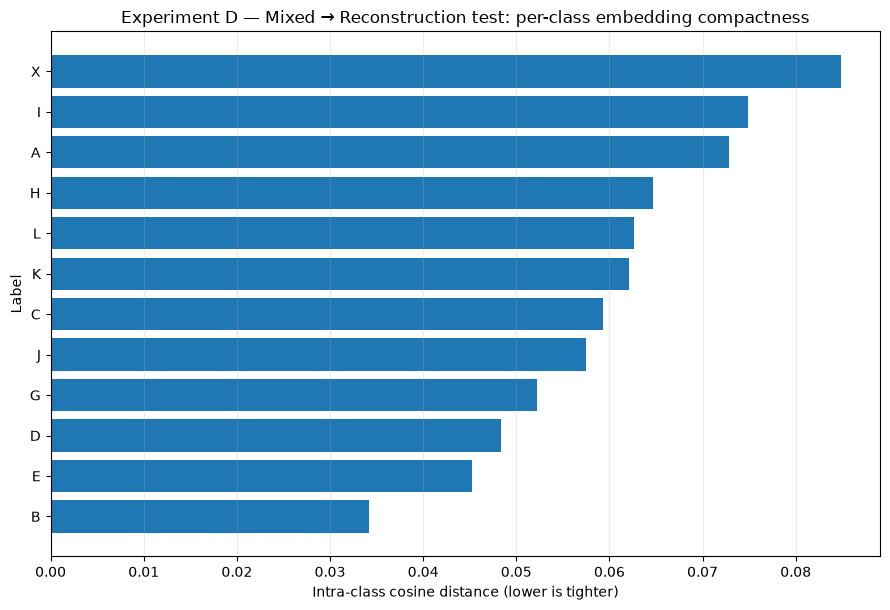

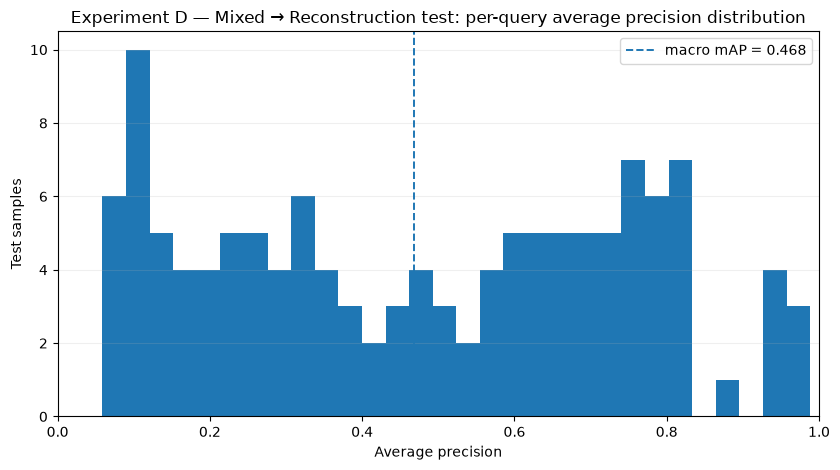

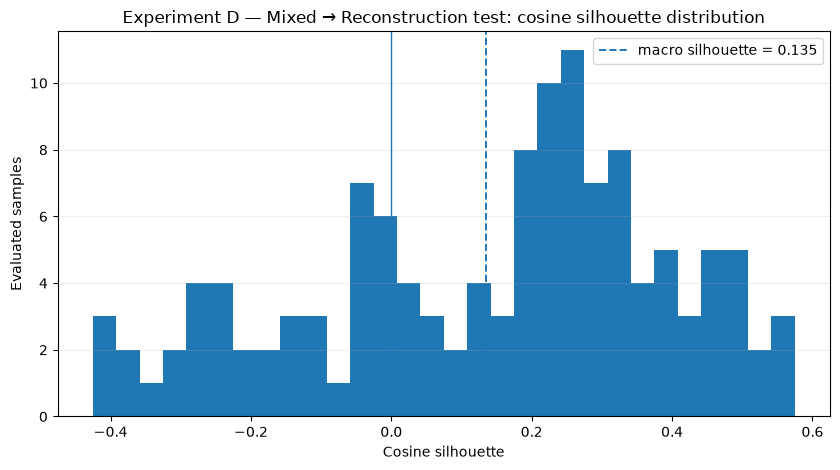

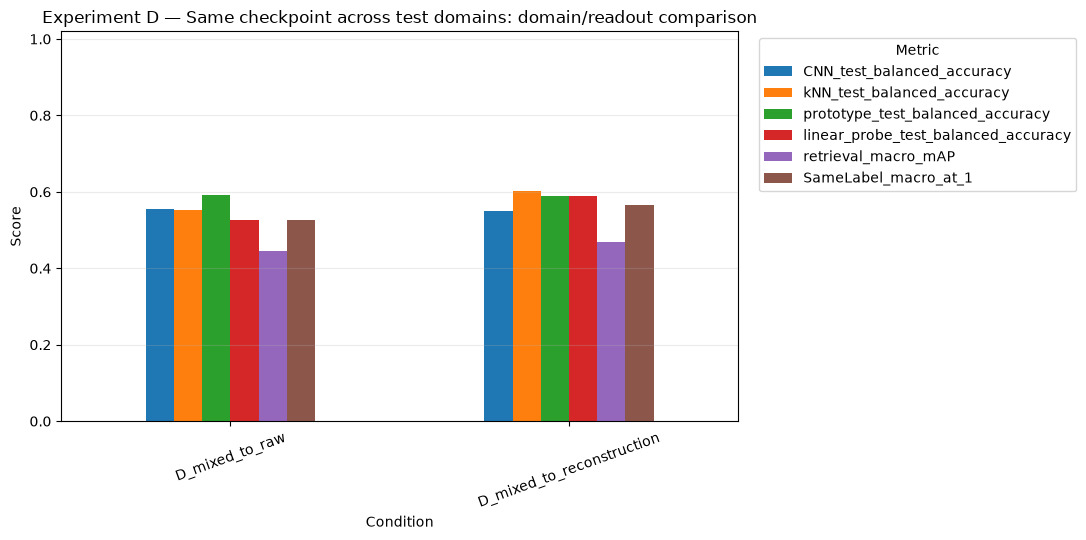

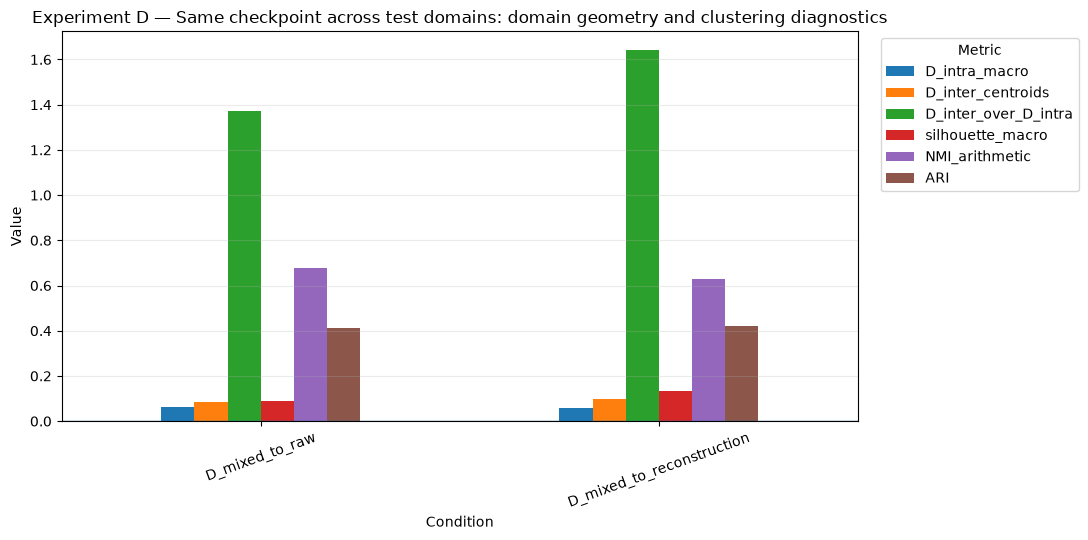

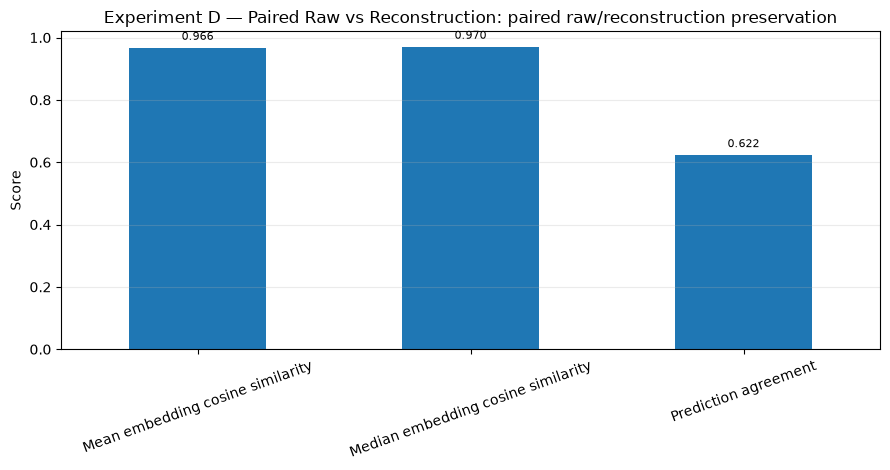

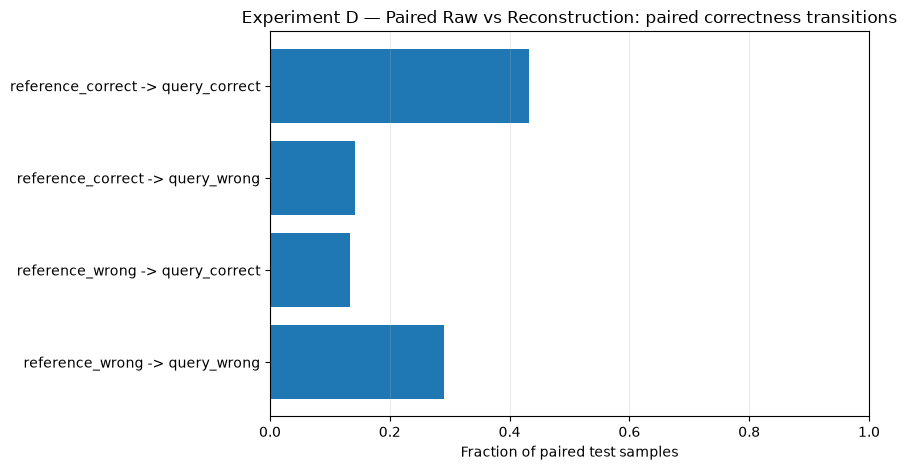

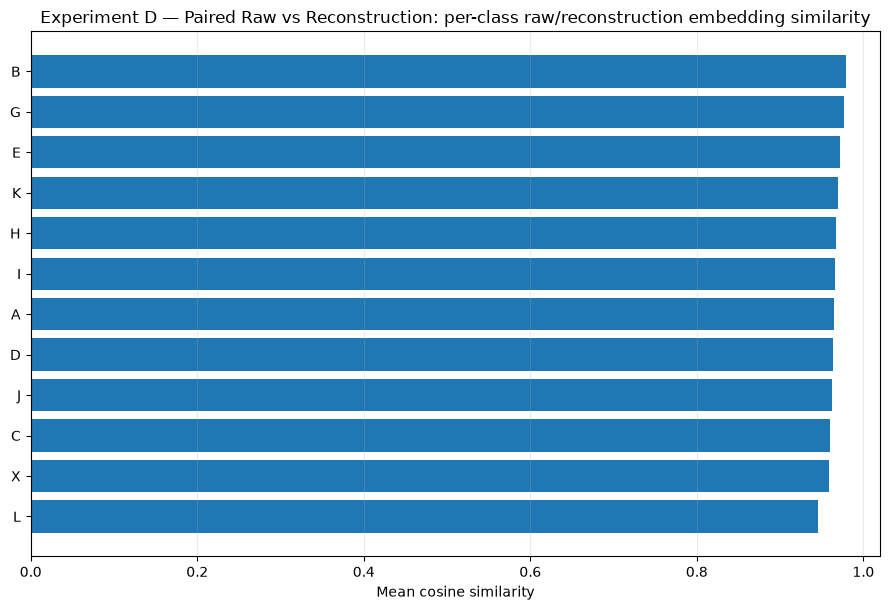

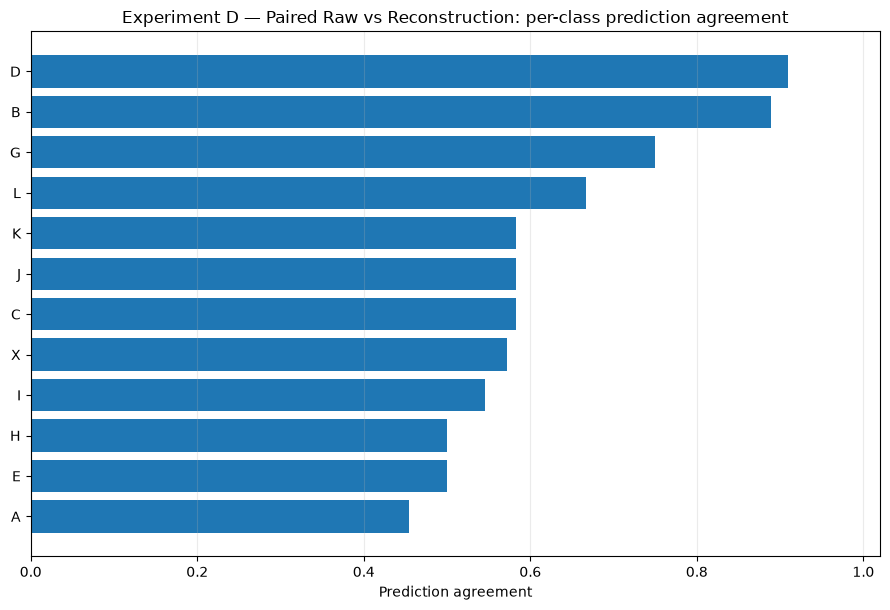

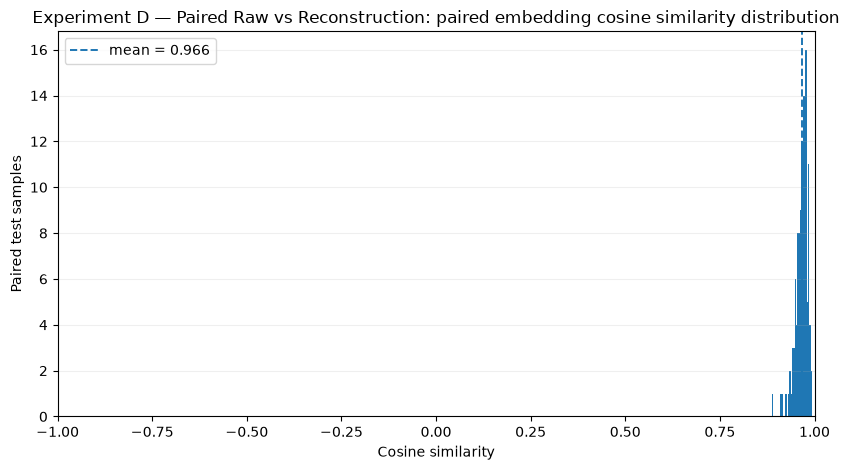

In [11]:
from snn.accel_reconstruction_eval.visualization import visualize_experiment_d

figures = visualize_experiment_d(run.output_dir)

## Interpretation checklist

Focus on these comparisons after A/B/C are available:

- **D mixed -> raw vs A raw -> raw:** does mixed training preserve or improve raw-domain generalization?
- **D mixed -> reconstruction vs B raw -> reconstruction:** does mixed training reduce the raw-to-reconstruction domain gap?
- **D mixed -> reconstruction vs C reconstruction -> reconstruction:** does mixed training sacrifice or improve reconstruction-domain specialization?
- **D paired cosine/agreement vs B paired cosine/agreement:** does mixed training make the representation more invariant to reconstruction?

A useful D result should ideally improve robustness to reconstruction without materially degrading raw held-out-user performance.
